# 2. Análisis exploratorio (I): partición, objetivo, análisis uni, bi y multivariado, y fuga

**Orden de trabajo.** Lo primero es reservar el conjunto de prueba. Todas las decisiones que
se usarán en el modelado (imputación, transformaciones, selección de variables, umbrales) se
toman solo con el conjunto de entrenamiento.

In [1]:
import sys
import warnings

sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

import utils as u

u.estilo()
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
rng = np.random.default_rng(u.SEMILLA)

## 2.0 Reserva del conjunto de prueba

Como los datos tienen tiempo, la partición es **cronológica**: la prueba contiene las semanas
objetivo de 2025 y el entrenamiento las semanas objetivo hasta el 27 de octubre de 2024. Entre
ambos se deja un hueco de 10 semanas, mayor que la ventana de 8 semanas usada para construir las
predictoras, para que ninguna fila de prueba use semanas que sirvieron como objetivo en
entrenamiento. Todos los corredores pueden aparecer en ambos conjuntos, porque el objetivo es
predecir el futuro de corredores conocidos; la generalización a territorios nuevos se evalúa
aparte con bloques espaciales (secciones 2.7 y 3).

In [2]:
panel = u.cargar_panel()
train, test = u.particion(panel)
excluidas = panel[(panel["semana_t1"] > u.FIN_TRAIN) & (panel["semana_t1"] < u.INICIO_TEST)]
tab = pd.DataFrame({
    "filas": [len(train), len(excluidas), len(test)],
    "desde (t+1)": [train["semana_t1"].min(), excluidas["semana_t1"].min(), test["semana_t1"].min()],
    "hasta (t+1)": [train["semana_t1"].max(), excluidas["semana_t1"].max(), test["semana_t1"].max()],
    "tasa de interrupción": [train[u.VAR_OBJETIVO].mean(), excluidas[u.VAR_OBJETIVO].mean(),
                             test[u.VAR_OBJETIVO].mean()],
    "corredores": [train.groupby(["mercado", "cod_mpio"]).ngroups,
                   excluidas.groupby(["mercado", "cod_mpio"]).ngroups,
                   test.groupby(["mercado", "cod_mpio"]).ngroups],
}, index=["entrenamiento", "hueco (descartado)", "prueba"])
tab

,filas,desde (t+1),hasta (t+1),tasa de interrupción,corredores
entrenamiento,622244,2018-01-29,2024-10-21,0.282232,4305
hueco (descartado),19211,2024-10-28,2024-12-30,0.289001,2258
prueba,103466,2025-01-06,2025-12-29,0.260433,3009


A partir de aquí **todo el EDA usa solo `train`**.

## 2.1 Variable objetivo

interrupcion_t1
sin interrupción    446627
interrupción        175617

Proporción de la clase minoritaria: 0.282; razón de desbalance 2.54:1
Casos de la clase minoritaria: 175,617


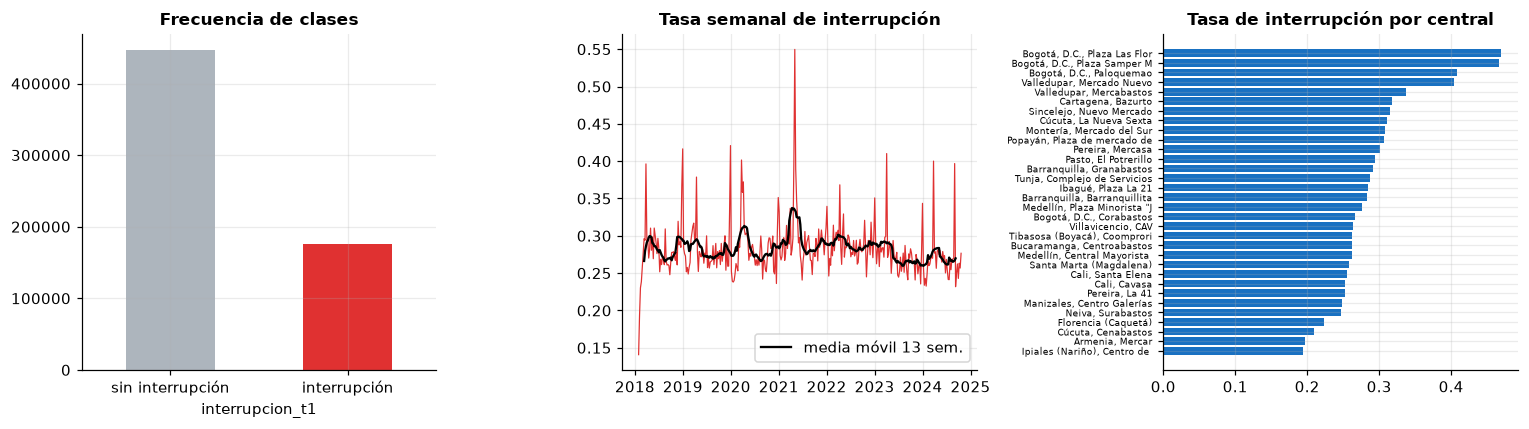

In [3]:
y = train[u.VAR_OBJETIVO]
conteo = y.value_counts().rename({0: "sin interrupción", 1: "interrupción"})
print(conteo.to_string())
print(f"\nProporción de la clase minoritaria: {y.mean():.3f}; razón de desbalance {(1 - y.mean()) / y.mean():.2f}:1")
print(f"Casos de la clase minoritaria: {int(y.sum()):,}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
conteo.plot.bar(ax=axes[0], color=["#adb5bd", "#e03131"], rot=0)
axes[0].set_title("Frecuencia de clases")
serie = train.groupby("semana_t1")[u.VAR_OBJETIVO].mean()
axes[1].plot(serie.index, serie.values, lw=0.8, color="#e03131")
axes[1].plot(serie.rolling(13, center=True).mean(), color="black", lw=1.5, label="media móvil 13 sem.")
axes[1].set_title("Tasa semanal de interrupción")
axes[1].legend()
por_mercado = train.groupby("mercado")[u.VAR_OBJETIVO].mean().sort_values()
axes[2].barh(range(len(por_mercado)), por_mercado.values, color="#1971c2")
axes[2].set_yticks(range(len(por_mercado)))
axes[2].set_yticklabels([m[:28] for m in por_mercado.index], fontsize=6)
axes[2].set_title("Tasa de interrupción por central")
plt.tight_layout()
plt.show()

In [4]:
print("Tasa de interrupción por origen PDET:")
print(train.groupby("pdet_origen")[u.VAR_OBJETIVO].agg(["mean", "size"]).to_string())
print("\nTasa por año de la semana objetivo:")
print(train.groupby(train["semana_t1"].dt.year)[u.VAR_OBJETIVO].agg(["mean", "size"]).round(3).to_string())

Tasa de interrupción por origen PDET:
                 mean    size
pdet_origen                  
0            0.276143  557100
1            0.334306   65144

Tasa por año de la semana objetivo:


            mean   size
semana_t1              
2018       0.282  83578
2019       0.281  90450
2020       0.281  89438
2021       0.297  90295
2022       0.288  92011
2023       0.274  94334
2024       0.270  82138


**Interpretación.**

* La clase positiva (interrupción) representa 28,2 % de las filas de entrenamiento: 175.617
  casos, desbalance moderado de 2,5:1. Hay casos de sobra para estimar la clase minoritaria,
  pero un clasificador trivial que siempre prediga "sin interrupción" ya obtiene 71,8 % de
  exactitud. **Implicación para la métrica:** la exactitud es engañosa; se priorizan el AUC-ROC,
  el AUC-PR (cuya línea base es 0,28), el F1 y el recall de la clase positiva, y se reporta la
  calibración.
* La tasa semanal es estable entre años (27 % a 30 %) pero tiene picos: el más visible coincide
  con el paro nacional de 2021 (semana del 3 de mayo: 55 % de corredores interrumpidos; 2021 es
  el año con la tasa más alta, 29,7 %), y hay picos recurrentes en las semanas de fin de año
  (semana ISO 1: 37 %) y de Semana Santa (semanas 13-14: 31-35 %). Esto anticipa dependencia temporal y choques
  comunes a muchos corredores a la vez (sección 2.6).
* La tasa varía entre centrales, de 19 % (Ipiales, Armenia) a 47 % (plazas Las Flores y Samper
  Mendoza en Bogotá, que son mercados minoristas con corredores pequeños), y es mayor en corredores
  que nacen en municipios PDET (33,4 % frente a 27,6 %).
* **Implicación para la validación:** como la tasa cambia en el tiempo y hay choques
  sincronizados, la validación debe ser cronológica y los intervalos de confianza deben
  remuestrear semanas completas. La estratificación no es necesaria porque ambas clases son
  abundantes en cualquier ventana temporal.

## 2.2 Análisis unidimensional

### Variables numéricas

In [5]:
num = u.NUMERICAS + ["base8"]
desc = train[num].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
desc["asimetria"] = train[num].skew()
desc["curtosis"] = train[num].kurt()
q1, q3 = train[num].quantile(0.25), train[num].quantile(0.75)
iqr = q3 - q1
desc["%_outliers_IQR"] = ((train[num] < q1 - 1.5 * iqr) | (train[num] > q3 + 1.5 * iqr)).mean() * 100
desc.round(3)

,count,mean,std,min,1%,25%,50%,75%,99%,max,asimetria,curtosis,%_outliers_IQR
log_base8,622244.0,1.647,1.119,0.002,0.108,0.760,1.394,2.316,4.720,6.242,0.880,0.219,1.165
ratio_t,622244.0,1.000,0.768,0.000,0.000,0.531,0.943,1.312,3.651,7.965,1.445,4.510,4.456
ratio_t_1,622052.0,0.999,0.745,0.000,0.000,0.554,0.950,1.303,3.556,7.965,1.410,4.569,4.445
cv8,622244.0,0.681,0.411,0.000,0.092,0.336,0.605,0.977,1.760,2.814,0.678,-0.045,0.460
pend8_rel,622244.0,-0.000,0.143,-1.083,-0.386,-0.072,0.000,0.071,0.386,0.953,-0.003,1.343,6.651
activas8,622244.0,6.886,1.457,4.000,4.000,6.000,8.000,8.000,8.000,8.000,-0.920,-0.688,0.000
activas26,622244.0,0.823,0.225,0.154,0.192,0.692,0.960,1.000,1.000,1.000,-1.135,0.130,1.050
n_envios8,622244.0,19.810,53.993,0.500,0.500,1.625,4.500,14.625,238.500,1103.000,7.961,90.425,12.900
n_alimentos8,622244.0,4.069,5.511,0.500,0.500,1.000,2.000,4.875,27.125,96.125,4.030,28.551,8.532
antig_sem,622244.0,173.801,101.562,3.000,6.000,85.000,173.000,261.000,350.000,354.000,0.037,-1.206,0.000


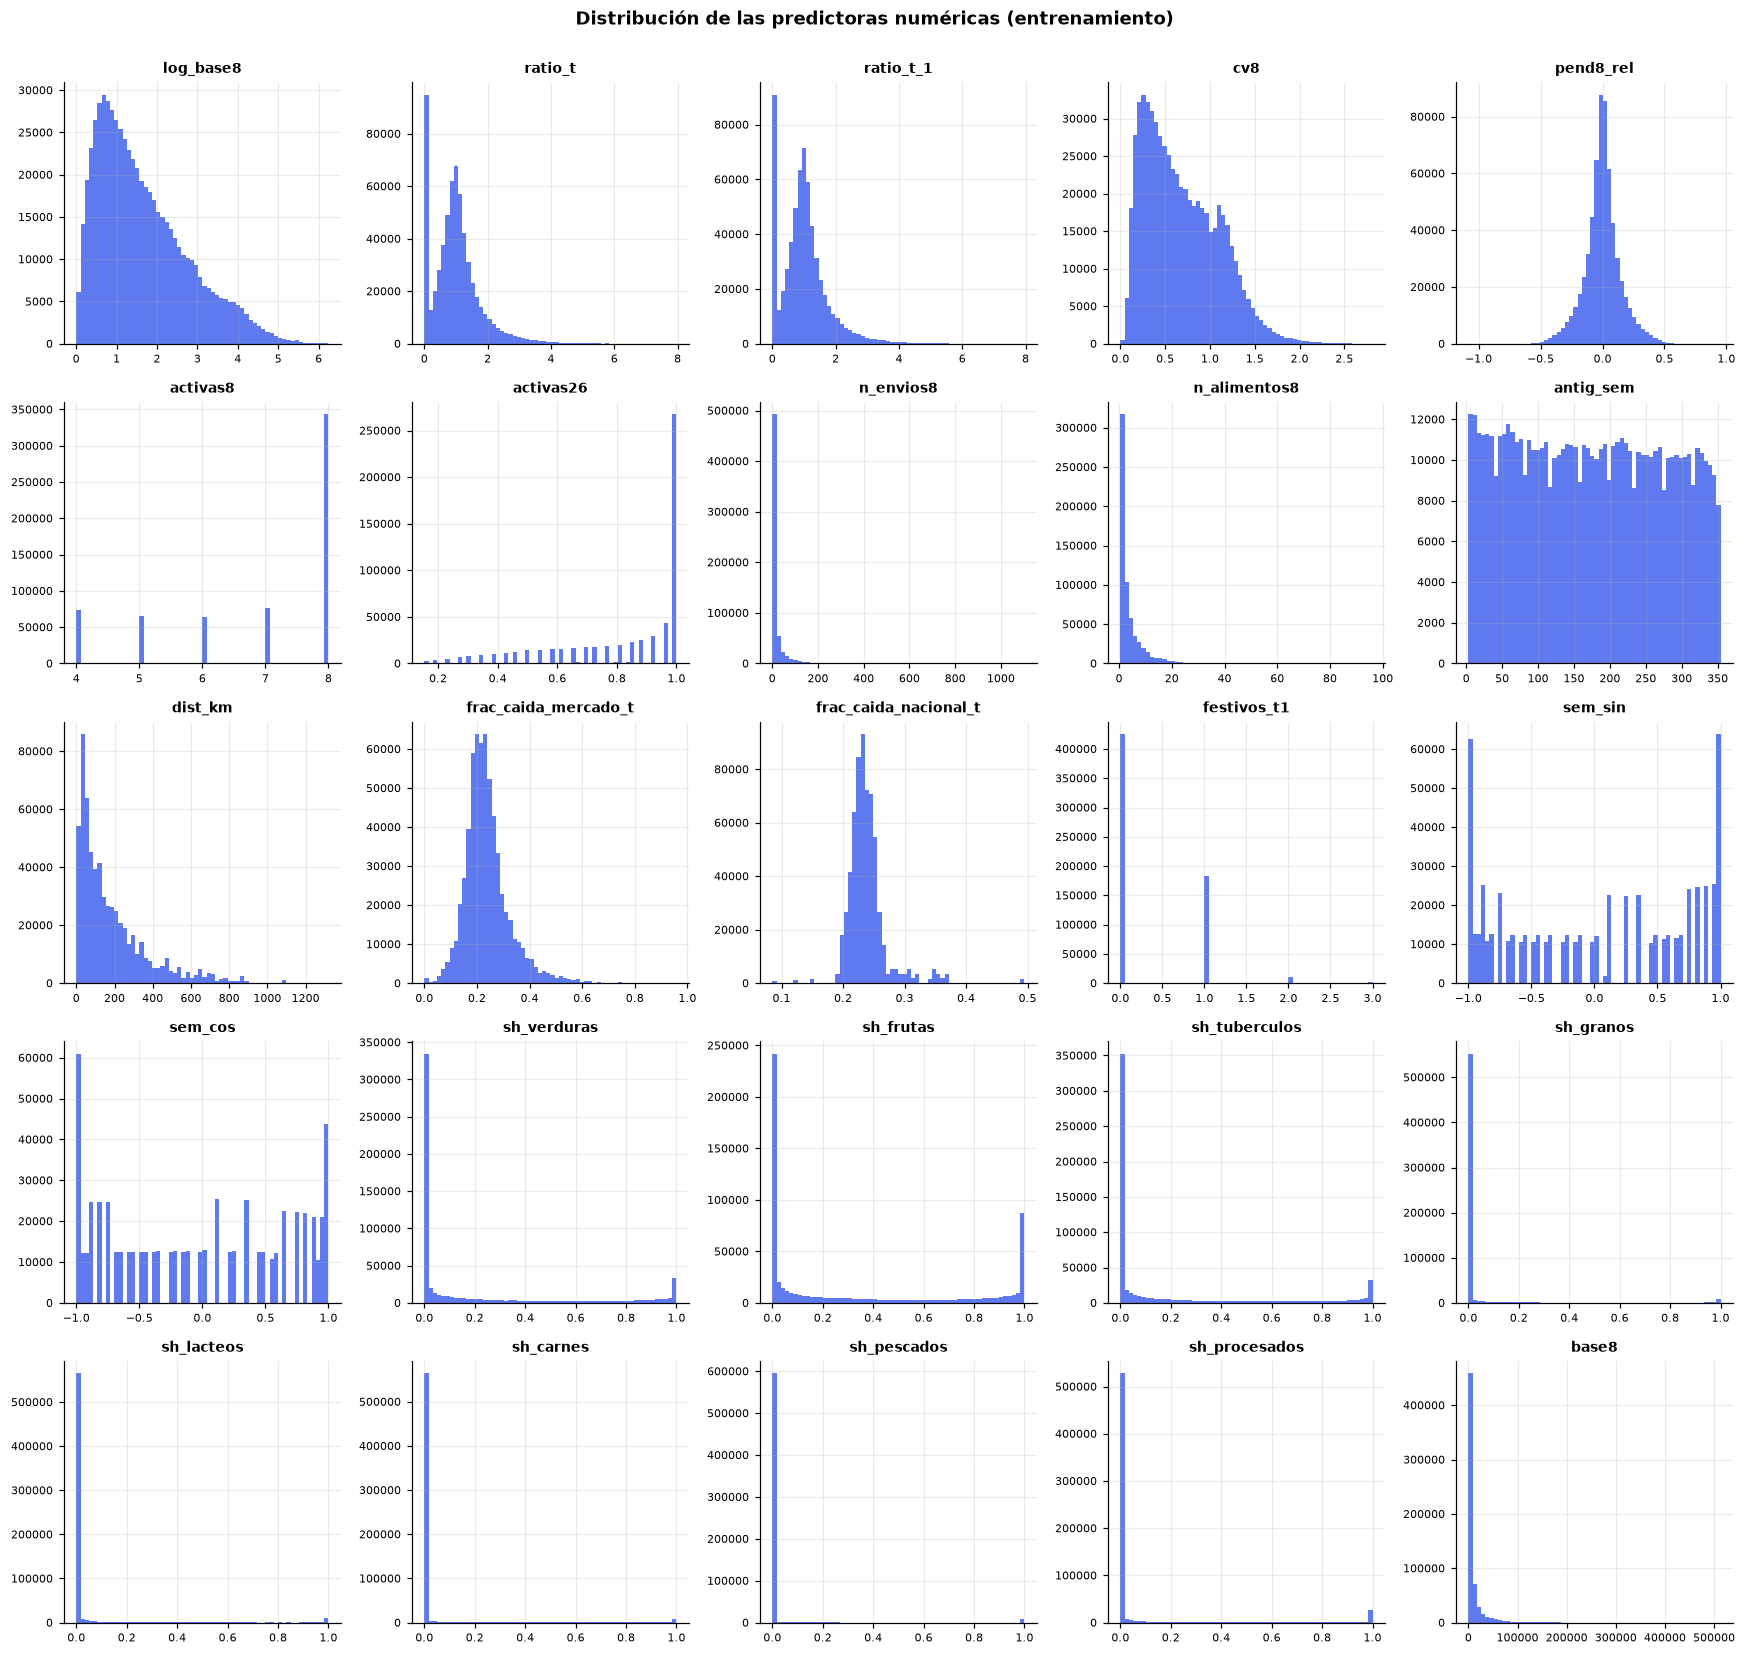

In [6]:
fig, axes = plt.subplots(5, 5, figsize=(16, 15))
for ax, c in zip(axes.ravel(), num):
    x = train[c].dropna()
    ax.hist(x, bins=60, color="#4263eb", alpha=0.85)
    ax.set_title(c, fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(num):]:
    ax.axis("off")
plt.suptitle("Distribución de las predictoras numéricas (entrenamiento)", y=1.0, fontweight="bold")
plt.tight_layout()
plt.show()

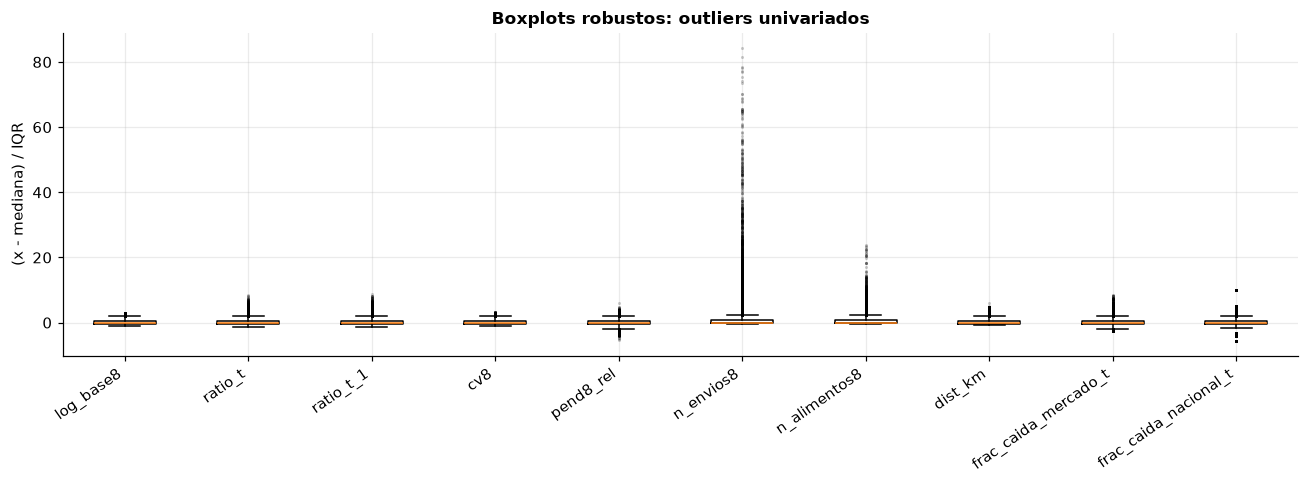

In [7]:
cols_box = ["log_base8", "ratio_t", "ratio_t_1", "cv8", "pend8_rel", "n_envios8", "n_alimentos8",
            "dist_km", "frac_caida_mercado_t", "frac_caida_nacional_t"]
z = (train[cols_box] - train[cols_box].median()) / (train[cols_box].quantile(0.75) - train[cols_box].quantile(0.25))
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.boxplot([z[c].dropna().sample(50000, random_state=u.SEMILLA) for c in cols_box], tick_labels=cols_box,
           showfliers=True, flierprops={"markersize": 1, "alpha": 0.2})
ax.set_ylabel("(x - mediana) / IQR")
ax.set_title("Boxplots robustos: outliers univariados")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

**Normalidad.** Con cientos de miles de filas cualquier prueba rechaza la normalidad por
desviaciones mínimas; se aplica la prueba de D'Agostino-Pearson a una submuestra de 5.000
filas solo como referencia, junto con la asimetría y la curtosis, que son más informativas.

In [8]:
sub = train.sample(5000, random_state=u.SEMILLA)
norm = pd.DataFrame({c: stats.normaltest(sub[c].dropna()) for c in
                     ["log_base8", "ratio_t", "cv8", "pend8_rel", "dist_km", "n_envios8"]},
                    index=["estadístico K2", "p"]).T
norm["log1p(x) asimetría"] = [np.log1p(train[c].clip(lower=0)).skew() for c in norm.index]
norm.round(4)

,estadístico K2,p,log1p(x) asimetría
log_base8,477.0264,0.0,0.1237
ratio_t,1541.0765,0.0,-0.0076
cv8,326.3381,0.0,0.2434
pend8_rel,137.7931,0.0,2.0083
dist_km,1624.1319,0.0,-0.9614
n_envios8,6750.5468,0.0,0.9343


**Interpretación.**

* **Escala del corredor.** `base8` (kg/día) va de 2 kg a 513 t, con asimetría 6,6 y curtosis 69;
  su logaritmo (`log_base8`) reduce la asimetría a 0,9. Lo mismo ocurre con `n_envios8`
  (asimetría 8,0) y `n_alimentos8` (4,0). **Decisión:** usar la versión logarítmica de estas
  variables en el modelo.
* **Razones de cambio** (`ratio_t`, `ratio_t_1`): centradas en 1 por construcción, con cola
  derecha larga (hasta 8 veces el promedio) y una masa en 0 (semanas sin carga). Tienen 4-5 % de
  outliers por IQR que corresponden a picos reales de abastecimiento. **Decisión:** recortar
  (winsorizar) en los percentiles 1 y 99 aprendidos en entrenamiento, en lugar de eliminar filas.
* `activas8` y `activas26` están acumuladas en su máximo: la mayoría de los corredores
  elegibles son muy regulares; los irregulares forman la cola izquierda.
* `dist_km` va de 0 (corredores locales) a 1.320 km, con asimetría 1,7; su logaritmo la
  sobrecorrige (−0,96), por lo que se usará `log1p` y estandarización.
* Las participaciones por grupo de alimentos (`sh_*`) tienen distribución en U o masa en cero:
  la mayoría de corredores se especializa en uno o dos grupos.
* La prueba de normalidad rechaza en todos los casos (p ≈ 0), como se esperaba; lo relevante es
  que la regresión logística no requiere normalidad de las predictoras, pero sí se beneficia de
  escalas comparables y de limitar la influencia de valores extremos.

### Variables categóricas y binarias

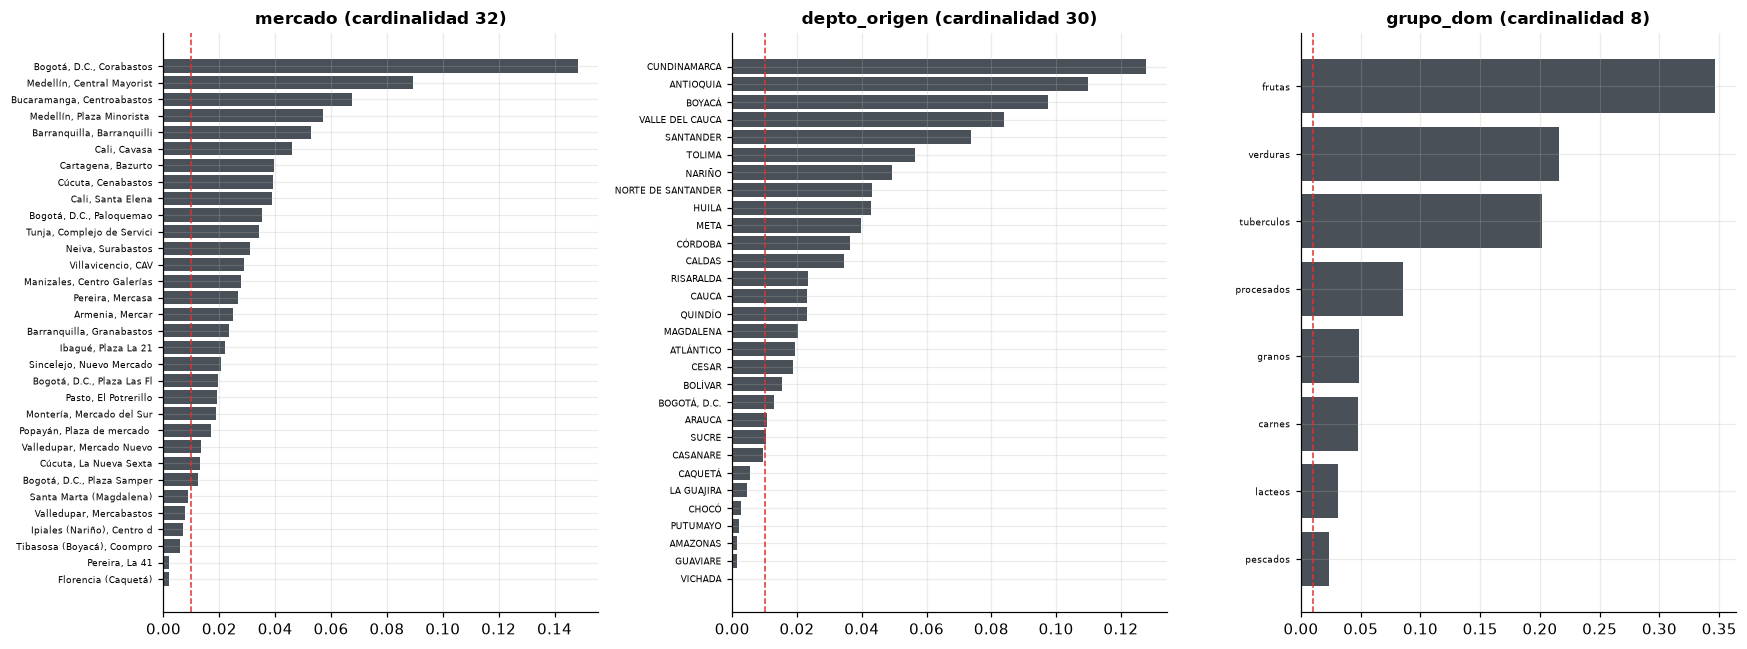

mercado: 32 categorías; 6 raras (< 1 %) que suman 3.34%
depto_origen: 30 categorías; 8 raras (< 1 %) que suman 2.72%
grupo_dom: 8 categorías; 0 raras (< 1 %) que suman 0.00%

mismo_depto    0.294613
local          0.016093
pdet_origen    0.104692


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, c in zip(axes, u.CATEGORICAS):
    f = train[c].value_counts(normalize=True)
    ax.barh(range(len(f)), f.values[::-1], color="#495057")
    ax.set_yticks(range(len(f)))
    ax.set_yticklabels([str(s)[:26] for s in f.index[::-1]], fontsize=6)
    ax.axvline(0.01, color="#e03131", ls="--", lw=1)
    ax.set_title(f"{c} (cardinalidad {train[c].nunique()})")
plt.tight_layout()
plt.show()

for c in u.CATEGORICAS:
    f = train[c].value_counts(normalize=True)
    print(f"{c}: {train[c].nunique()} categorías; {(f < 0.01).sum()} raras (< 1 %) que suman {f[f < 0.01].sum():.2%}")
print()
print(train[u.BINARIAS].mean().rename("proporción de 1").to_string())

**Interpretación.** La central de destino tiene 32 niveles y el departamento de origen 30;
en ambos casos entre 6 y 8 categorías son raras (< 1 % de las filas, 3 % en total), como
Florencia, Tibasosa o departamentos amazónicos. **Decisión:** en el `OneHotEncoder` agrupar las
categorías con frecuencia menor a 1 % en una categoría "infrecuente" para evitar coeficientes
inestables. Solo 10,5 % de las filas corresponde a corredores PDET y 1,6 % a corredores locales
(origen = municipio de la central).

## 2.3 Análisis bidimensional

### Numéricas vs numéricas

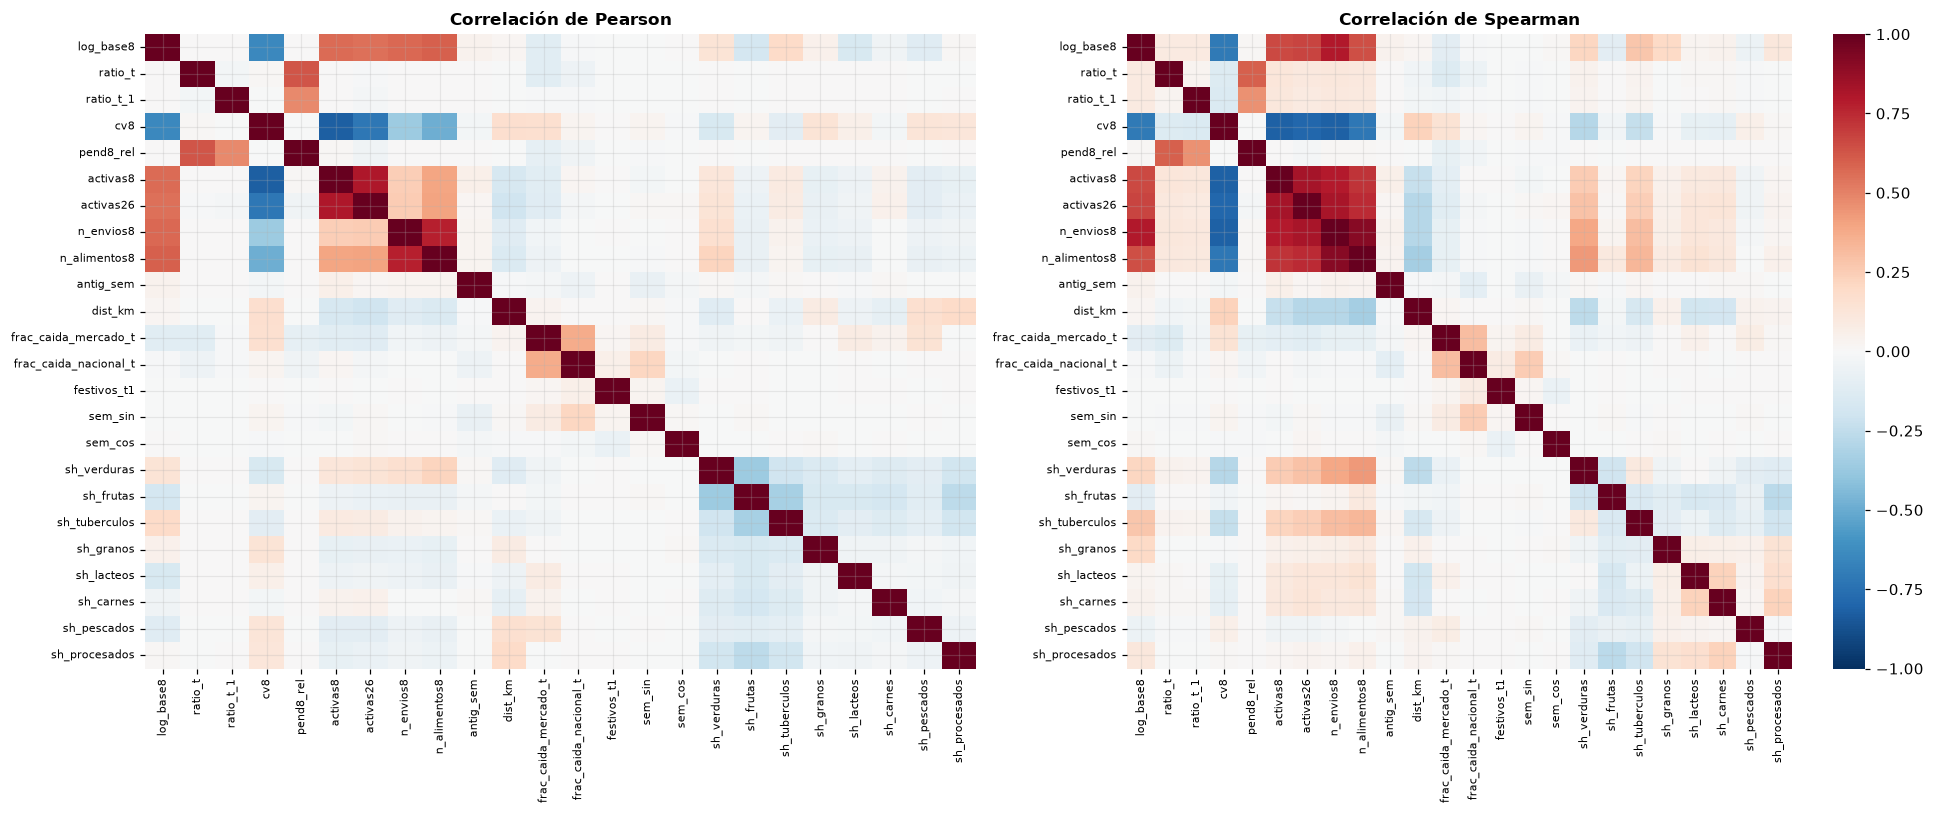

Pares con |rho de Spearman| > 0,6:
n_envios8  n_alimentos8    0.909
activas8   activas26       0.833
activas26  n_envios8       0.825
cv8        activas8       -0.820
           n_envios8      -0.813
log_base8  n_envios8       0.802
cv8        activas26      -0.793
activas8   n_envios8       0.792
activas26  n_alimentos8    0.747
activas8   n_alimentos8    0.725
cv8        n_alimentos8   -0.720
log_base8  cv8            -0.704
           activas26       0.680
           activas8        0.657
           n_alimentos8    0.645


In [10]:
corr_s = train[u.NUMERICAS].corr(method="spearman")
corr_p = train[u.NUMERICAS].corr(method="pearson")
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
for ax, cm, t in zip(axes, [corr_p, corr_s], ["Pearson", "Spearman"]):
    sns.heatmap(cm, cmap="RdBu_r", vmin=-1, vmax=1, ax=ax, cbar=ax is axes[1],
                xticklabels=True, yticklabels=True)
    ax.set_title(f"Correlación de {t}")
    ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

pares = corr_s.where(np.triu(np.ones(corr_s.shape, bool), 1)).stack().sort_values(key=np.abs, ascending=False)
print("Pares con |rho de Spearman| > 0,6:")
print(pares[pares.abs() > 0.6].round(3).to_string())

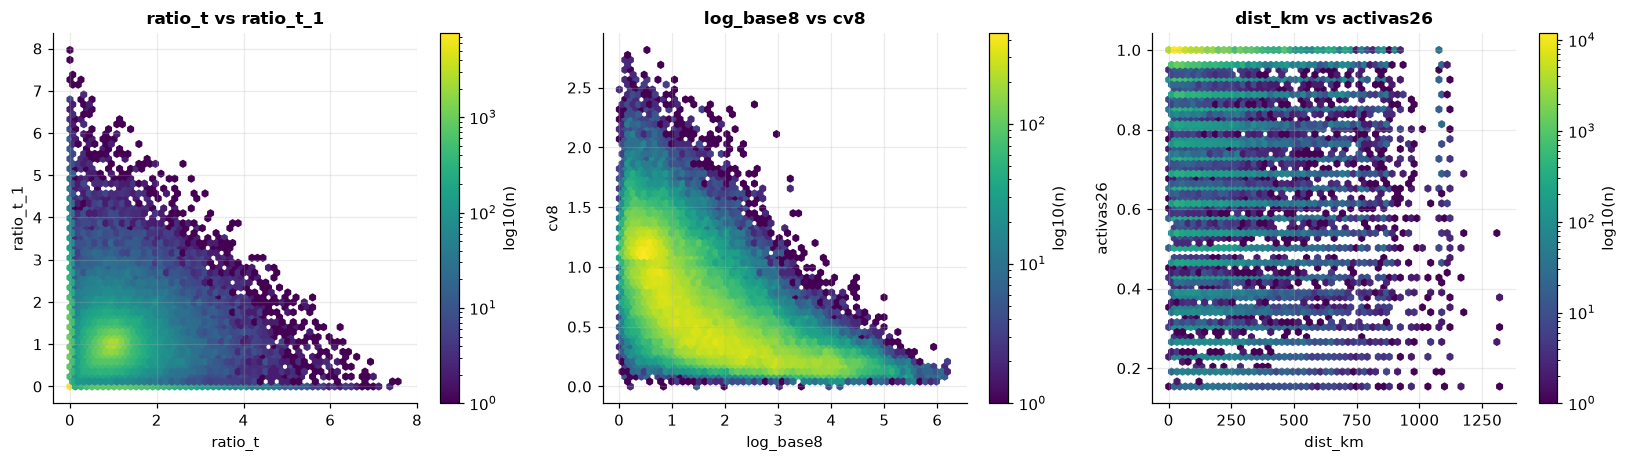

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
s = train.sample(150000, random_state=u.SEMILLA)
for ax, (a, b) in zip(axes, [("ratio_t", "ratio_t_1"), ("log_base8", "cv8"), ("dist_km", "activas26")]):
    hb = ax.hexbin(s[a], s[b], gridsize=60, bins="log", cmap="viridis", mincnt=1)
    ax.set_xlabel(a)
    ax.set_ylabel(b)
    ax.set_title(f"{a} vs {b}")
    plt.colorbar(hb, ax=ax, label="log10(n)")
plt.tight_layout()
plt.show()

### Predictoras numéricas vs variable objetivo

Para cada predictora se compara su distribución entre clases con Mann-Whitney (no se asume
normalidad), se reporta el **tamaño del efecto** (correlación biserial de rangos, equivalente a
2·AUC − 1) y se corrigen los p-valores por comparaciones múltiples con Holm.

In [12]:
filas = []
for c in u.NUMERICAS + u.BINARIAS:
    a = train.loc[y == 1, c].dropna()
    b = train.loc[y == 0, c].dropna()
    mw = stats.mannwhitneyu(a, b)
    auc = mw.statistic / (len(a) * len(b))
    filas.append({"variable": c, "mediana_interr": a.median(), "mediana_no": b.median(),
                  "p": mw.pvalue, "rbc": 2 * auc - 1})
biv = pd.DataFrame(filas)
biv["p_holm"] = multipletests(biv["p"], method="holm")[1]
biv["|rbc|"] = biv["rbc"].abs()
biv.sort_values("|rbc|", ascending=False).round(4).reset_index(drop=True)

,variable,mediana_interr,mediana_no,p,rbc,p_holm,|rbc|
0,cv8,0.9332,0.4843,0.0000,0.5061,0.0000,0.5061
1,n_envios8,1.8750,6.8750,0.0000,-0.4852,0.0000,0.4852
2,activas26,0.7200,1.0000,0.0000,-0.4742,0.0000,0.4742
3,n_alimentos8,1.1250,2.6250,0.0000,-0.4338,0.0000,0.4338
4,activas8,6.0000,8.0000,0.0000,-0.4184,0.0000,0.4184
5,log_base8,0.9088,1.6534,0.0000,-0.4035,0.0000,0.4035
6,ratio_t,0.6867,0.9871,0.0000,-0.2123,0.0000,0.2123
7,ratio_t_1,0.7497,0.9839,0.0000,-0.1718,0.0000,0.1718
8,sh_verduras,0.0000,0.0180,0.0000,-0.1700,0.0000,0.1700
9,pend8_rel,-0.0301,0.0059,0.0000,-0.1622,0.0000,0.1622


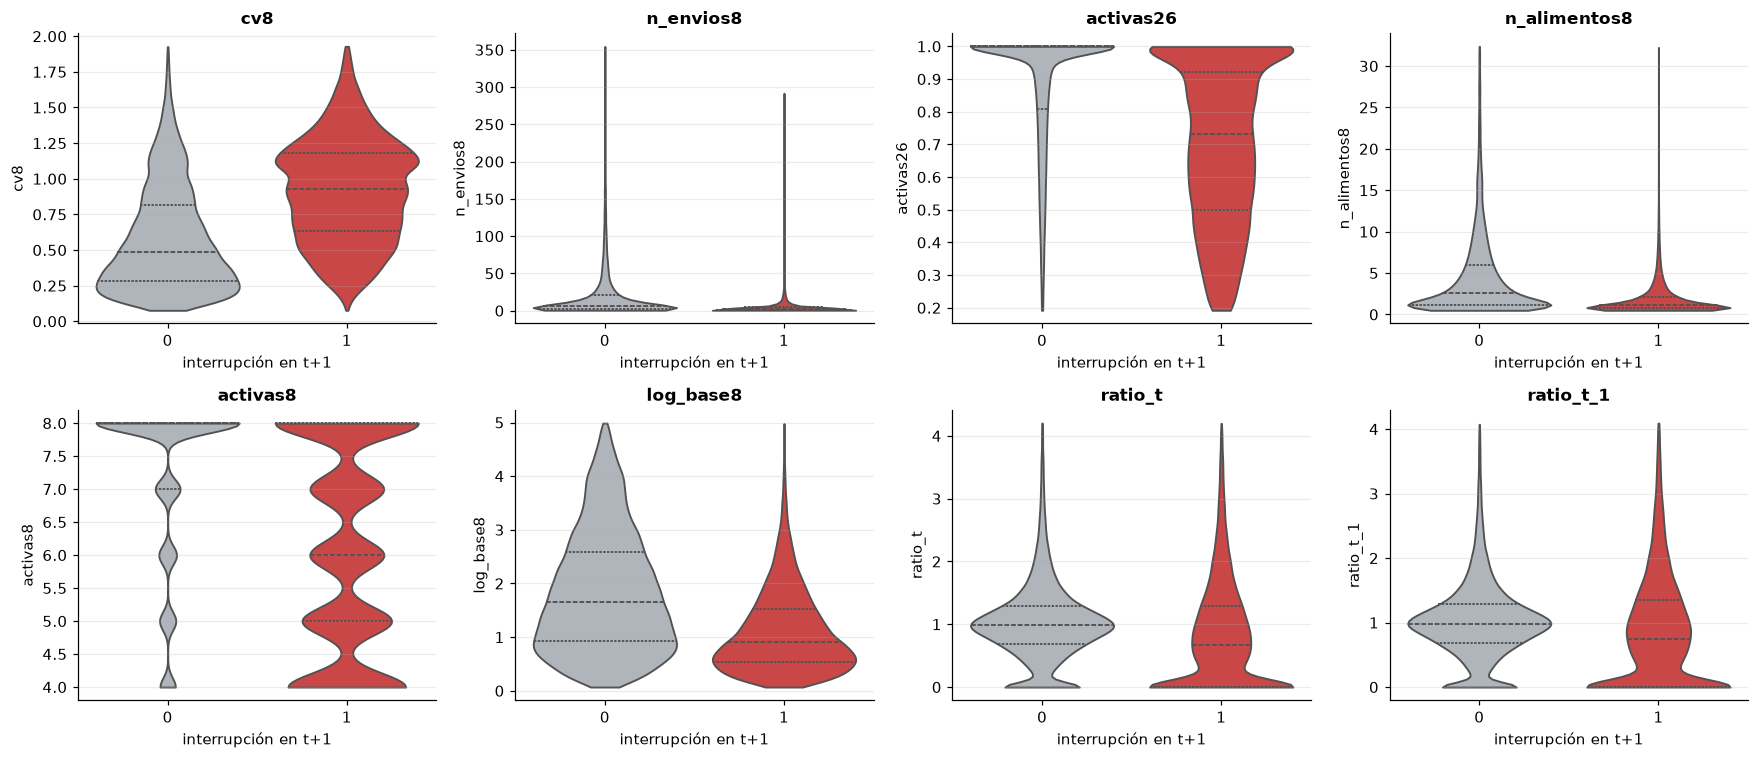

In [13]:
top = biv.sort_values("|rbc|", ascending=False)["variable"].head(8).tolist()
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
ss = train.sample(80000, random_state=u.SEMILLA)
for ax, c in zip(axes.ravel(), top):
    lim = ss[c].quantile([0.005, 0.995])
    sns.violinplot(data=ss[ss[c].between(*lim)], x=u.VAR_OBJETIVO, y=c, ax=ax, cut=0,
                   palette=["#adb5bd", "#e03131"], inner="quartile")
    ax.set_title(c)
    ax.set_xlabel("interrupción en t+1")
plt.tight_layout()
plt.show()

**Interpretación.**

* Con más de 600 mil filas todas las diferencias son "significativas" incluso tras la corrección
  de Holm, así que lo que importa es el tamaño del efecto. Las variables con mayor efecto
  (|rbc| > 0,4) describen **regularidad y tamaño del corredor**: coeficiente de variación
  (`cv8`), número de cargas y productos, semanas activas y escala (`log_base8`). Los corredores
  pequeños e irregulares se interrumpen mucho más que los grandes y estables.
* La **dinámica reciente** (`ratio_t`, `ratio_t_1`, `pend8_rel`) tiene un efecto intermedio
  (|rbc| ≈ 0,16-0,21): una caída en *t* o una tendencia negativa anticipan una caída en *t+1*.
* La distancia tiene un efecto pequeño pero coherente (mediana 155 km en interrupciones frente a
  112 km), y los corredores dentro del mismo departamento son más estables.
* Calendario (`festivos_t1`, `sem_sin`, `sem_cos`), PDET y la mayoría de las participaciones por
  grupo tienen efectos casi nulos de forma aislada (|rbc| < 0,03), aunque pueden aportar en
  combinación con otras variables.
* La relación de `ratio_t` con la probabilidad de interrupción no es monótona (ver hexbin y
  violines): la tasa de interrupción es 57 % cuando `ratio_t` = 0, baja a 16 % cuando está entre
  0,75 y 1,5 y vuelve a subir a 40 % cuando supera 3, porque un pico suele ser seguido de regreso
  a la media. Es una relación en forma de U. Esto motiva recortar las razones y, en capítulos
  posteriores, probar modelos no lineales.

### Categóricas vs objetivo y categóricas entre sí

In [14]:
filas = []
for c in u.CATEGORICAS + u.BINARIAS:
    t_ = pd.crosstab(train[c], y)
    chi2, p, dof, _ = stats.chi2_contingency(t_, correction=False)
    filas.append({"variable": c, "categorías": t_.shape[0], "chi2": chi2, "gl": dof, "p": p,
                  "V_Cramer": u.cramers_v(t_)})
cat = pd.DataFrame(filas)
cat["p_holm"] = multipletests(cat["p"], method="holm")[1]
cat.round(4)

,variable,categorías,chi2,gl,p,V_Cramer,p_holm
0,mercado,32,8364.0117,31,0.0,0.1159,0.0
1,depto_origen,30,8732.9012,29,0.0,0.1185,0.0
2,grupo_dom,8,10777.3663,7,0.0,0.1316,0.0
3,mismo_depto,2,6428.6364,1,0.0,0.1016,0.0
4,local,2,2418.8821,1,0.0,0.0623,0.0
5,pdet_origen,2,973.9812,1,0.0,0.0396,0.0


In [15]:
print("Tabla de contingencia grupo dominante x interrupción (proporción por fila):")
print(pd.crosstab(train["grupo_dom"], y, normalize="index").round(3).to_string())
print("\nAsociación entre categóricas (V de Cramér):")
vv = pd.DataFrame(index=u.CATEGORICAS + ["pdet_origen"], columns=u.CATEGORICAS + ["pdet_origen"], dtype=float)
for a in vv.index:
    for b in vv.columns:
        vv.loc[a, b] = 1.0 if a == b else u.cramers_v(pd.crosstab(train[a], train[b]))
print(vv.round(3).to_string())

Tabla de contingencia grupo dominante x interrupción (proporción por fila):
interrupcion_t1      0      1
grupo_dom                    
carnes           0.766  0.234
frutas           0.703  0.297
granos           0.588  0.412
lacteos          0.662  0.338
pescados         0.548  0.452
procesados       0.638  0.362
tuberculos       0.759  0.241
verduras         0.781  0.219

Asociación entre categóricas (V de Cramér):


              mercado  depto_origen  grupo_dom  pdet_origen
mercado         1.000         0.314      0.249        0.206
depto_origen    0.314         1.000      0.322        0.538
grupo_dom       0.249         0.322      1.000        0.138
pdet_origen     0.206         0.538      0.138        1.000


### Información mutua (relaciones no lineales)

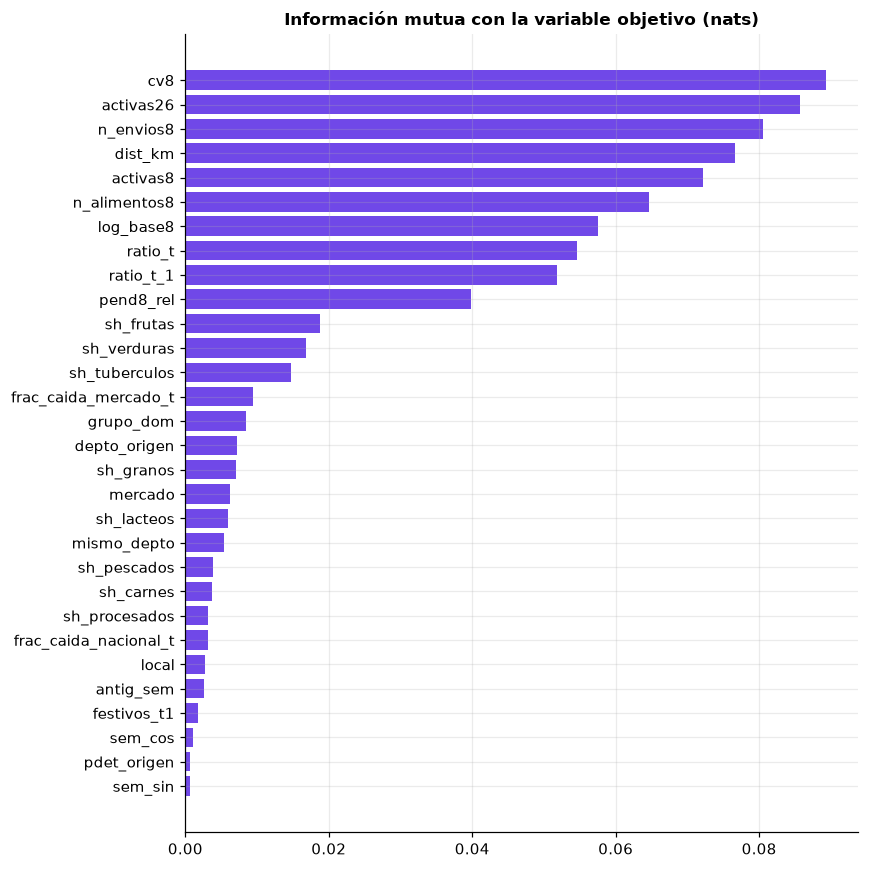

In [16]:
from sklearn.feature_selection import mutual_info_classif

mi_s = train.sample(120000, random_state=u.SEMILLA)
Xmi = mi_s[u.NUMERICAS + u.BINARIAS].fillna(mi_s[u.NUMERICAS + u.BINARIAS].median())
mi = pd.Series(mutual_info_classif(Xmi, mi_s[u.VAR_OBJETIVO], random_state=u.SEMILLA,
                                   discrete_features=[c in u.BINARIAS for c in Xmi.columns]),
               index=Xmi.columns)
for c in u.CATEGORICAS:
    codes = mi_s[c].astype("category").cat.codes.to_frame()
    mi[c] = mutual_info_classif(codes, mi_s[u.VAR_OBJETIVO], discrete_features=True,
                                random_state=u.SEMILLA)[0]
mi = mi.sort_values()
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(mi.index, mi.values, color="#7048e8")
ax.set_title("Información mutua con la variable objetivo (nats)")
plt.tight_layout()
plt.show()

### Multicolinealidad (VIF)

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_s = train.sample(60000, random_state=u.SEMILLA)[u.NUMERICAS + u.BINARIAS].dropna()
Xv = (vif_s - vif_s.mean()) / vif_s.std()
Xv = Xv.drop(columns=["sh_procesados"])  # las participaciones suman 1: se omite una categoría
Xv.insert(0, "const", 1.0)
vif = pd.Series([variance_inflation_factor(Xv.values, i) for i in range(1, Xv.shape[1])],
                index=Xv.columns[1:]).sort_values(ascending=False)
vif.round(2).to_frame("VIF").T

,activas8,cv8,n_alimentos8,sh_frutas,activas26,log_base8,n_envios8,pend8_rel,sh_verduras,sh_tuberculos,ratio_t,ratio_t_1,sh_carnes,sh_granos,sh_lacteos,dist_km,mismo_depto,sh_pescados,frac_caida_mercado_t,local,frac_caida_nacional_t,sem_sin,pdet_origen,antig_sem,festivos_t1,sem_cos
VIF,4.48,3.99,3.24,3.24,3.15,3.03,3.0,2.83,2.71,2.53,2.18,1.71,1.58,1.55,1.46,1.44,1.4,1.32,1.25,1.24,1.23,1.06,1.05,1.02,1.01,1.01


**Interpretación.**

* Las categóricas tienen asociación débil a moderada con el objetivo (V de Cramér entre 0,04 y
  0,13). El grupo dominante es la más informativa: los corredores de pescados (45 %), granos
  (41 %) y procesados (36 %) se interrumpen más que los de verduras (22 %) y tubérculos (24 %),
  que son productos de abastecimiento continuo y de corta vida útil.
* PDET está fuertemente asociado con el departamento de origen (V = 0,54), lo esperable porque
  los PDET se concentran en ciertas subregiones. En el modelo lineal parte del efecto PDET será
  absorbido por el departamento, lo que debe tenerse en cuenta al interpretar el coeficiente.
* **Información mutua.** Confirma el ranking de Mann-Whitney y añade la central de destino y el
  departamento como fuentes de información no lineal. Las variables de calendario aportan casi
  nada por sí solas.
* **Multicolinealidad.** Hay correlaciones de Spearman altas entre las medidas de tamaño y
  regularidad (`n_envios8`-`n_alimentos8` 0,91; `activas8`-`activas26` 0,83; `cv8`-`activas8`
  −0,82), pero todos los VIF quedan por debajo de 5 (máximo 4,5 en `activas8`) tras omitir una de
  las participaciones, que suman 1 por construcción. **Decisión:** conservar todas las
  variables y usar regularización L2 en la regresión logística, que estabiliza los coeficientes
  de variables correlacionadas; al interpretar coeficientes se leerán en bloque (tamaño,
  regularidad, dinámica), no individualmente.

## 2.4 Análisis multivariado

### PCA exploratorio

Varianza explicada acumulada: [0.18  0.263 0.33  0.392 0.452 0.51  0.566 0.615 0.662 0.709]
Componentes para 80 % de la varianza: 12 de 22
Componentes con autovalor > 1 (Kaiser): 12


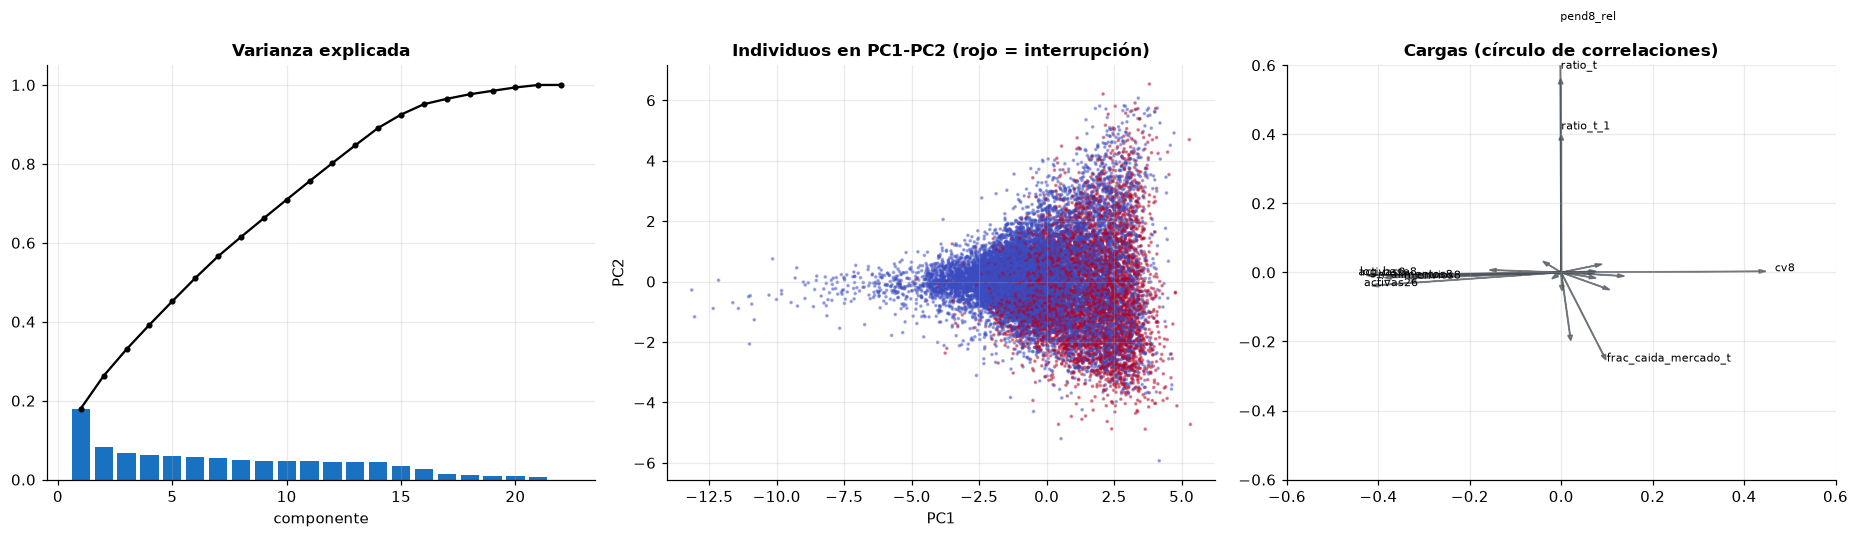

,PC1,PC2,norma
pend8_rel,-0.002,0.677,0.677
ratio_t,-0.001,0.546,0.546
cv8,0.433,0.003,0.433
activas8,-0.411,-0.008,0.411
log_base8,-0.408,-0.008,0.408
activas26,-0.400,-0.037,0.401
ratio_t_1,0.000,0.383,0.383
n_alimentos8,-0.372,-0.014,0.372
n_envios8,-0.319,-0.016,0.319
frac_caida_mercado_t,0.092,-0.239,0.256


In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_s = train.sample(100000, random_state=u.SEMILLA)
cols_pca = [c for c in u.NUMERICAS if c not in ("sem_sin", "sem_cos")]
Xp = StandardScaler().fit_transform(pca_s[cols_pca].fillna(pca_s[cols_pca].median()))
pca = PCA(random_state=u.SEMILLA).fit(Xp)
ev = pca.explained_variance_ratio_
print("Varianza explicada acumulada:", np.round(np.cumsum(ev)[:10], 3))
print(f"Componentes para 80 % de la varianza: {np.argmax(np.cumsum(ev) >= 0.8) + 1} de {len(cols_pca)}")
print(f"Componentes con autovalor > 1 (Kaiser): {(pca.explained_variance_ > 1).sum()}")

Z = pca.transform(Xp)[:, :2]
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].bar(range(1, len(ev) + 1), ev, color="#1971c2")
axes[0].plot(range(1, len(ev) + 1), np.cumsum(ev), "o-", color="black", ms=3)
axes[0].set_title("Varianza explicada")
axes[0].set_xlabel("componente")
idx = rng.choice(len(Z), 20000, replace=False)
sc = axes[1].scatter(Z[idx, 0], Z[idx, 1], c=pca_s[u.VAR_OBJETIVO].values[idx], cmap="coolwarm",
                     s=2, alpha=0.4)
axes[1].set_title("Individuos en PC1-PC2 (rojo = interrupción)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
cargas = pd.DataFrame(pca.components_[:2].T, index=cols_pca, columns=["PC1", "PC2"])
for v, (a, b) in cargas.iterrows():
    axes[2].arrow(0, 0, a, b, color="#495057", head_width=0.01, alpha=0.7)
    if np.hypot(a, b) > 0.2:
        axes[2].text(a * 1.08, b * 1.08, v, fontsize=7)
axes[2].set_xlim(-0.6, 0.6)
axes[2].set_ylim(-0.6, 0.6)
axes[2].set_title("Cargas (círculo de correlaciones)")
plt.tight_layout()
plt.show()
cargas.assign(norma=np.hypot(cargas.PC1, cargas.PC2)).sort_values("norma", ascending=False).head(10).round(3)

### Outliers multivariados

In [19]:
from sklearn.covariance import MinCovDet
from sklearn.ensemble import IsolationForest

cols_out = ["log_base8", "ratio_t", "ratio_t_1", "cv8", "pend8_rel", "activas26", "n_envios8", "dist_km"]
mo = train.sample(40000, random_state=u.SEMILLA)[cols_out + [u.VAR_OBJETIVO]].dropna()
Xo = mo[cols_out].copy()
Xo["n_envios8"] = np.log1p(Xo["n_envios8"])
Xo["dist_km"] = np.log1p(Xo["dist_km"])
mcd = MinCovDet(random_state=u.SEMILLA).fit(Xo)
d2 = mcd.mahalanobis(Xo)
corte = stats.chi2.ppf(0.999, df=len(cols_out))
iso = IsolationForest(contamination="auto", random_state=u.SEMILLA).fit(Xo)
anom = iso.predict(Xo) == -1
mo["out_mahal"], mo["out_iso"] = d2 > corte, anom
print(f"Outliers por Mahalanobis robusta (chi2 0,999): {mo['out_mahal'].mean():.2%}")
print(f"Outliers por Isolation Forest: {mo['out_iso'].mean():.2%}")
print(f"Coincidencia (ambos): {(mo['out_mahal'] & mo['out_iso']).mean():.2%}")
print("\nTasa de interrupción según condición de outlier:")
print(mo.groupby("out_mahal")[u.VAR_OBJETIVO].mean().rename("Mahalanobis").to_string())
print(mo.groupby("out_iso")[u.VAR_OBJETIVO].mean().rename("IsolationForest").to_string())
print("\nMedianas de outliers vs resto (Mahalanobis):")
print(mo.groupby("out_mahal")[cols_out].median().T.round(3).to_string())

Outliers por Mahalanobis robusta (chi2 0,999): 47.04%
Outliers por Isolation Forest: 15.35%
Coincidencia (ambos): 13.01%

Tasa de interrupción según condición de outlier:
out_mahal
False    0.131274
True     0.454202
out_iso
False    0.255044
True     0.438345

Medianas de outliers vs resto (Mahalanobis):
out_mahal   False    True 
log_base8   2.136    0.823
ratio_t     0.972    0.809
ratio_t_1   0.979    0.850
cv8         0.357    0.997
pend8_rel  -0.001    0.006
activas26   1.000    0.654
n_envios8  12.625    1.625
dist_km    86.697  170.408


### Subpoblaciones de corredores (clustering exploratorio)

Se resume cada corredor con su perfil promedio en entrenamiento y se agrupan con K-means.

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

perfil = train.groupby(["mercado", "cod_mpio"]).agg(
    log_base8=("log_base8", "mean"), cv8=("cv8", "mean"), activas26=("activas26", "mean"),
    dist_km=("dist_km", "first"), n_alimentos8=("n_alimentos8", "mean"),
    sh_frutas=("sh_frutas", "mean"), sh_verduras=("sh_verduras", "mean"),
    sh_tuberculos=("sh_tuberculos", "mean"), tasa_interr=(u.VAR_OBJETIVO, "mean"),
    n=(u.VAR_OBJETIVO, "size"), pdet=("pdet_origen", "first"))
perfil = perfil[perfil["n"] >= 20]
cols_k = ["log_base8", "cv8", "activas26", "dist_km", "n_alimentos8", "sh_frutas", "sh_verduras", "sh_tuberculos"]
Xk = StandardScaler().fit_transform(np.column_stack([perfil[cols_k].drop(columns="dist_km"),
                                                     np.log1p(perfil["dist_km"])]))
sil = {k: silhouette_score(Xk, KMeans(k, n_init=10, random_state=u.SEMILLA).fit_predict(Xk)) for k in range(2, 9)}
print("Silueta por k:", {k: round(v, 3) for k, v in sil.items()})
k_opt = max(sil, key=sil.get)
perfil["cluster"] = KMeans(k_opt, n_init=10, random_state=u.SEMILLA).fit_predict(Xk)
res = perfil.groupby("cluster").agg(corredores=("n", "size"), **{c: (c, "median") for c in cols_k},
                                    tasa_interr=("tasa_interr", "mean"), pdet=("pdet", "mean"))
res.round(3)

Silueta por k: {2: 0.303, 3: 0.213, 4: 0.247, 5: 0.259, 6: 0.264, 7: 0.273, 8: 0.287}


,corredores,log_base8,cv8,activas26,dist_km,n_alimentos8,sh_frutas,sh_verduras,sh_tuberculos,tasa_interr,pdet
cluster,,,,,,,,,,,
0,2141,0.762,1.015,0.564,183.467,0.956,0.19,0.004,0.002,0.508,0.136
1,992,2.108,0.426,0.991,81.502,4.525,0.10,0.117,0.077,0.135,0.079


**Interpretación.**

* **Dimensionalidad efectiva.** La primera componente explica 18 % y se necesitan 12 de 22
  componentes para llegar al 80 %: la información está repartida y no hay una estructura de
  baja dimensión dominante. PC1 es un eje de **tamaño y regularidad** (cargas positivas de `cv8`,
  negativas de `activas8`, `log_base8`, `activas26`, `n_alimentos8`) y PC2 un eje de
  **dinámica reciente** (`pend8_rel`, `ratio_t`, `ratio_t_1`). Las interrupciones se concentran
  en el lado positivo de PC1 (corredores pequeños e irregulares), pero se superponen mucho con la
  clase negativa: no hay separación lineal limpia, lo que anticipa un desempeño moderado del
  modelo lineal.
* **Outliers multivariados.** La distancia de Mahalanobis robusta marca 47 % de las filas como
  atípicas y el Isolation Forest 15 %. Una proporción tan alta no indica errores: indica que los
  datos son una **mezcla de subpoblaciones** y que el núcleo que estima el MCD corresponde a los
  corredores grandes y regulares. Los "outliers" son corredores pequeños (mediana 1,6 cargas por
  semana frente a 12,6), irregulares y lejanos, y su tasa de interrupción es 45 % frente a 13 %.
  **Decisión:** no eliminarlos; son precisamente la población de mayor riesgo.
* **Subpoblaciones.** El clustering de perfiles de corredor elige k = 2 por silueta (0,30):
  (0) 2.141 corredores pequeños, irregulares, lejanos y poco diversificados, con 51 % de semanas
  con interrupción y 13,6 % de origen PDET; (1) 992 corredores consolidados, cercanos y
  diversificados, con 13,5 % de interrupción. La silueta modesta indica un continuo más que dos
  grupos nítidos. La heterogeneidad sugiere que un único modelo lineal puede quedarse corto y
  que interacciones o modelos por segmento son candidatos para los siguientes entregables.

## 2.5 Auditoría de fuga de datos

### Disponibilidad de cada variable en el momento de la predicción

In [21]:
auditoria = pd.DataFrame([
    ("tasa_t1", "NO", "Es el abastecimiento de t+1: define la variable objetivo", "Descartada"),
    ("interrupcion_t1", "NO", "Variable objetivo", "Objetivo"),
    ("semana_t1", "Sí (índice)", "Fecha a predecir; solo se usa para partir y para calendario", "No es predictora"),
    ("cod_mpio, mercado+cod_mpio", "Sí", "Identificadores de corredor: permitirían memorizar la tasa histórica del corredor", "Descartado cod_mpio; mercado se conserva como contexto (32 niveles)"),
    ("tasa_t, base8", "Sí", "Se usan solo a través de razones y logaritmos; base8 es el denominador del objetivo", "Auxiliares (se usan log_base8 y ratio_t)"),
    ("ratio_t, ratio_t_1, cv8, pend8_rel, activas8/26", "Sí", "Ventanas que terminan en t", "Predictoras"),
    ("n_envios8, n_alimentos8, sh_*", "Sí", "Ventanas que terminan en t", "Predictoras"),
    ("frac_caida_mercado_t, frac_caida_nacional_t", "Sí", "Calculadas con la semana t de todos los corredores; no usan t+1", "Predictoras (en observación)"),
    ("festivos_t1, sem_sin, sem_cos", "Sí", "Calendario de t+1, conocido de antemano", "Predictoras"),
    ("dist_km, mismo_depto, local, pdet_origen, depto_origen", "Sí", "Atributos fijos del corredor", "Predictoras"),
    ("días de encuesta en t+1", "NO", "Solo se conoce al final de t+1; se usó para definir la población, no como predictora", "Descartada"),
], columns=["variable", "¿disponible en t?", "justificación", "decisión"])
auditoria

,variable,¿disponible en t?,justificación,decisión
0,tasa_t1,NO,Es el abastecimiento de t+1: define la variabl...,Descartada
1,interrupcion_t1,NO,Variable objetivo,Objetivo
2,semana_t1,Sí (índice),Fecha a predecir; solo se usa para partir y pa...,No es predictora
3,"cod_mpio, mercado+cod_mpio",Sí,Identificadores de corredor: permitirían memor...,Descartado cod_mpio; mercado se conserva como ...
4,"tasa_t, base8",Sí,Se usan solo a través de razones y logaritmos;...,Auxiliares (se usan log_base8 y ratio_t)
5,"ratio_t, ratio_t_1, cv8, pend8_rel, activas8/26",Sí,Ventanas que terminan en t,Predictoras
6,"n_envios8, n_alimentos8, sh_*",Sí,Ventanas que terminan en t,Predictoras
7,"frac_caida_mercado_t, frac_caida_nacional_t",Sí,Calculadas con la semana t de todos los corred...,Predictoras (en observación)
8,"festivos_t1, sem_sin, sem_cos",Sí,"Calendario de t+1, conocido de antemano",Predictoras
9,"dist_km, mismo_depto, local, pdet_origen, dept...",Sí,Atributos fijos del corredor,Predictoras


### Desempeño univariado (AUC) de cada variable

Un AUC univariado cercano a 1 sería señal de fuga. Se incluyen, como control, las variables
descartadas `tasa_t1` y la razón `tasa_t1 / base8`.

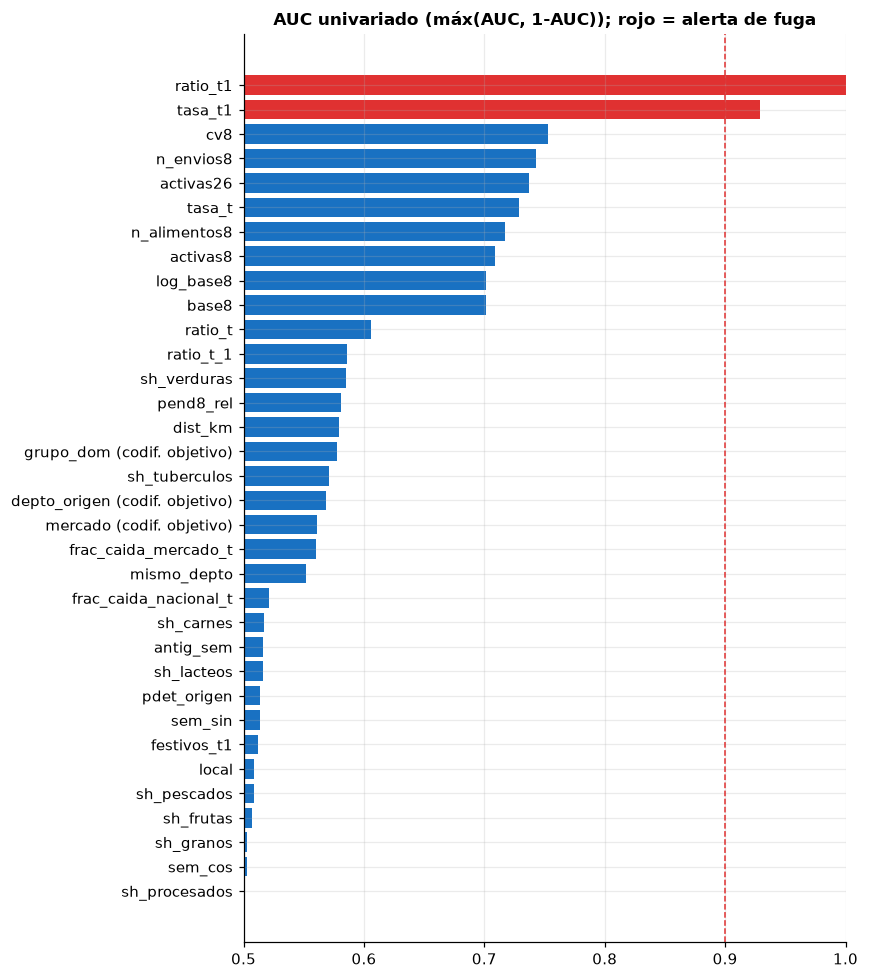

,ratio_t1,tasa_t1,cv8,n_envios8,activas26,tasa_t,n_alimentos8,activas8,log_base8,base8,ratio_t,ratio_t_1,sh_verduras,pend8_rel,dist_km,grupo_dom (codif. objetivo),sh_tuberculos,depto_origen (codif. objetivo),mercado (codif. objetivo),frac_caida_mercado_t,mismo_depto,frac_caida_nacional_t,sh_carnes,antig_sem,sh_lacteos,pdet_origen,sem_sin,festivos_t1,local,sh_pescados,sh_frutas,sh_granos,sem_cos,sh_procesados
AUC,1.0,0.929,0.753,0.743,0.737,0.729,0.717,0.709,0.702,0.702,0.606,0.586,0.585,0.581,0.579,0.578,0.571,0.568,0.561,0.56,0.551,0.521,0.517,0.516,0.516,0.513,0.513,0.512,0.509,0.509,0.507,0.503,0.502,0.501


In [22]:
from sklearn.metrics import roc_auc_score

control = train.assign(ratio_t1=train["tasa_t1"] / train["base8"])
aucs = {}
for c in u.NUMERICAS + u.BINARIAS + ["tasa_t1", "ratio_t1", "base8", "tasa_t"]:
    x = control[c].fillna(control[c].median())
    a = roc_auc_score(control[u.VAR_OBJETIVO], x)
    aucs[c] = max(a, 1 - a)
for c in u.CATEGORICAS:
    tasa = control.groupby(c)[u.VAR_OBJETIVO].transform("mean")
    aucs[c + " (codif. objetivo)"] = roc_auc_score(control[u.VAR_OBJETIVO], tasa)
aucs = pd.Series(aucs).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 9))
colores = ["#e03131" if v > 0.9 else "#1971c2" for v in aucs.values]
ax.barh(aucs.index[::-1], aucs.values[::-1], color=colores[::-1])
ax.axvline(0.9, color="#e03131", ls="--", lw=1)
ax.set_xlim(0.5, 1.0)
ax.set_title("AUC univariado (máx(AUC, 1-AUC)); rojo = alerta de fuga")
plt.tight_layout()
plt.show()
aucs.round(3).to_frame("AUC").T

### Duplicados y entidades repetidas entre particiones

In [23]:
clave = ["mercado", "cod_mpio", "semana"]
inter = pd.merge(train[clave], test[clave], on=clave)
corr_tr = set(map(tuple, train[["mercado", "cod_mpio"]].drop_duplicates().to_numpy()))
corr_te = set(map(tuple, test[["mercado", "cod_mpio"]].drop_duplicates().to_numpy()))
print(f"Filas corredor-semana presentes en ambas particiones: {len(inter)}")
print(f"Duplicados de clave dentro del panel: {panel.duplicated(clave).sum()}")
print(f"Corredores de prueba también vistos en entrenamiento: {len(corr_te & corr_tr):,} de {len(corr_te):,} ({len(corr_te & corr_tr) / len(corr_te):.1%})")
print(f"Filas de prueba de corredores nuevos: {(~test.set_index(['mercado', 'cod_mpio']).index.isin(list(corr_tr))).mean():.1%}")
print(f"Máxima semana de las ventanas de prueba (t-7) vs. última semana objetivo de entrenamiento: "
      f"{(test['semana'].min() - pd.Timedelta(weeks=7)).date()} > {u.FIN_TRAIN.date()}")

Filas corredor-semana presentes en ambas particiones: 0
Duplicados de clave dentro del panel: 0
Corredores de prueba también vistos en entrenamiento: 2,815 de 3,009 (93.6%)
Filas de prueba de corredores nuevos: 1.6%
Máxima semana de las ventanas de prueba (t-7) vs. última semana objetivo de entrenamiento: 2024-11-11 > 2024-10-27


**Interpretación y lista de variables.**

* **Control positivo.** Las variables construidas con *t+1* delatan la fuga: `ratio_t1` tiene
  AUC = 1,00 (define el objetivo) y `tasa_t1` 0,93. Ambas están **descartadas**.
* **Ninguna predictora admitida supera AUC 0,76.** La más fuerte es `cv8` (0,75), seguida de
  `n_envios8` y `activas26` (0,74). Son valores coherentes con una relación genuina
  (los corredores irregulares se interrumpen más) y no con una fuga.
* **En observación:** `frac_caida_mercado_t` y `frac_caida_nacional_t` agregan la semana *t* de
  todos los corredores. No usan *t+1*, pero la fila del propio corredor entra en el promedio de
  su central; con decenas de corredores por central el efecto es pequeño (AUC 0,56 y 0,52). Se
  mantienen como predictoras y se verificará que no inflen el desempeño.
* **Identificadores.** `cod_mpio` y el par corredor se excluyen: el modelo aprendería la tasa
  histórica de cada corredor en lugar de patrones generalizables. `mercado` y `depto_origen` se
  conservan como contexto de baja cardinalidad; su AUC con codificación por objetivo es 0,56-0,57.
* **Entidades entre particiones.** No hay filas repetidas entre entrenamiento y prueba, y las
  ventanas de prueba empiezan (11/11/2024) después de la última semana objetivo de entrenamiento
  (27/10/2024). El 93,6 % de los corredores de prueba ya se vio en entrenamiento, lo cual es
  coherente con el objetivo (predecir el futuro de corredores conocidos) y no constituye fuga,
  porque no se usan identificadores. La capacidad de generalizar a territorios no vistos se mide
  aparte con validación por bloques espaciales (capítulo 4).